Failure mode analysis

=== Statistics ===
True Positives : 1745
False Positives : 721
False Negatives : 2286
Misclassifications : 106
Poor Localization (IoU < 0.75) : 696

=== False negative ===
class
vehicle       1085
pedestrian    1021
bike           180
dtype: int64

=== Missed objects size ===
Aire moyenne : 1340 pixels²
Aire médiane : 366 pixels²

=== False positive ===
class
pedestrian    446
vehicle       246
bike           29
dtype: int64

=== False positive confidence ===
Average : 0.359
Median : 0.326


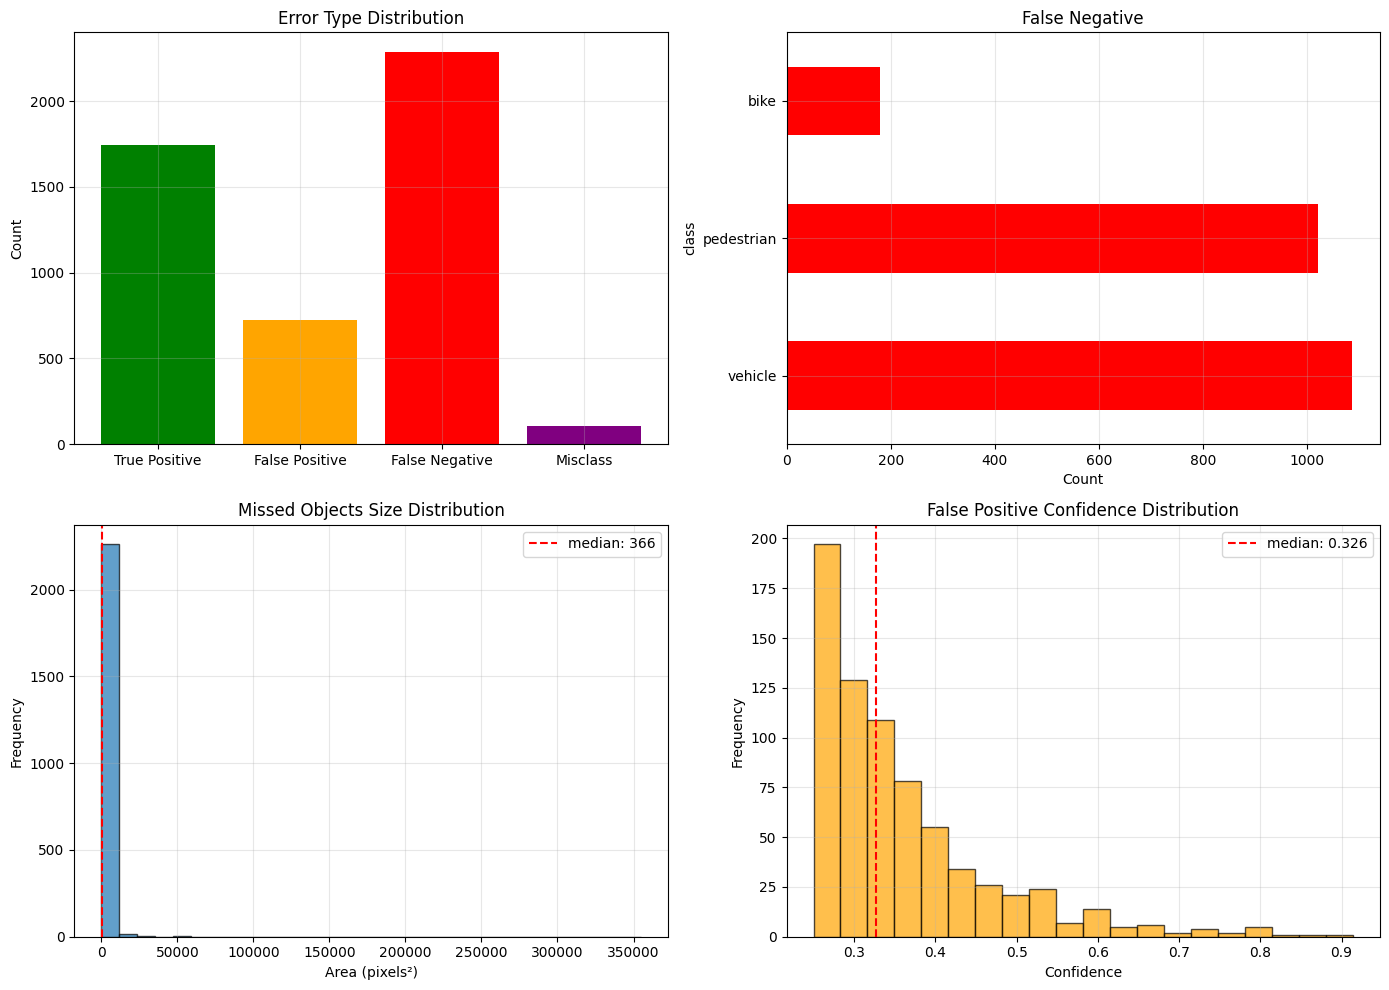

In [3]:
import sys
sys.path.append('..')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

model = YOLO('../models/yolo26n_visdrone/weights/best.pt')

val_img_dir = Path('../data/processed/val/images')
val_label_dir = Path('../data/processed/val/labels')

CLASS_NAMES = ["pedestrian", "vehicle", "bike"]

def compute_iou(box1, box2):
    """Compute IoU between two bounding boxes [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

def load_ground_truth(label_path, img_width, img_height):
    """Get ground truth ann"""
    boxes = []
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            
            cls, x_center, y_center, w, h = map(float, parts)
            
            x1 = (x_center - w/2) * img_width
            y1 = (y_center - h/2) * img_height
            x2 = (x_center + w/2) * img_width
            y2 = (y_center + h/2) * img_height
            
            boxes.append({
                'class': int(cls),
                'bbox': [x1, y1, x2, y2],
                'matched': False
            })
    
    return boxes

def analyze_predictions(img_path, label_path, conf_threshold=0.25, iou_threshold=0.5):
    """Analyze preds vs ground truth for one image"""

    results = model.predict(img_path, conf=conf_threshold, verbose=False)
    
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    
    gt_boxes = load_ground_truth(label_path, w, h)
    
    pred_boxes = []
    if len(results[0].boxes) > 0:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        classes = results[0].boxes.cls.cpu().numpy()
        confs = results[0].boxes.conf.cpu().numpy()
        
        for box, cls, conf in zip(boxes, classes, confs):
            pred_boxes.append({
                'class': int(cls),
                'bbox': box,
                'conf': conf,
                'matched': False
            })
    
    errors = {
        'true_positives': [],
        'false_positives': [],
        'false_negatives': [],
        'misclassifications': [],
        'poor_localization': []  # TP but IoU < 0.75
    }
    
    for pred in pred_boxes:
        best_iou = 0
        best_gt = None
        
        for gt in gt_boxes:
            if gt['matched']:
                continue
            iou = compute_iou(pred['bbox'], gt['bbox'])
            if iou > best_iou:
                best_iou = iou
                best_gt = gt
        
        if best_iou >= iou_threshold:
            if pred['class'] == best_gt['class']:
                errors['true_positives'].append({
                    'img': img_path.name,
                    'class': CLASS_NAMES[pred['class']],
                    'iou': best_iou,
                    'conf': pred['conf']
                })
                
                if best_iou < 0.75:
                    errors['poor_localization'].append({
                        'img': img_path.name,
                        'class': CLASS_NAMES[pred['class']],
                        'iou': best_iou
                    })
                
                best_gt['matched'] = True
                pred['matched'] = True
            else:
                errors['misclassifications'].append({
                    'img': img_path.name,
                    'predicted': CLASS_NAMES[pred['class']],
                    'true': CLASS_NAMES[best_gt['class']],
                    'iou': best_iou,
                    'conf': pred['conf']
                })
                best_gt['matched'] = True
                pred['matched'] = True
        else:
            errors['false_positives'].append({
                'img': img_path.name,
                'class': CLASS_NAMES[pred['class']],
                'conf': pred['conf']
            })

    for gt in gt_boxes:
        if not gt['matched']:
            errors['false_negatives'].append({
                'img': img_path.name,
                'class': CLASS_NAMES[gt['class']],
                'bbox_area': (gt['bbox'][2] - gt['bbox'][0]) * (gt['bbox'][3] - gt['bbox'][1])
            })
    
    return errors

print("Failure mode analysis")

all_errors = {
    'true_positives': [],
    'false_positives': [],
    'false_negatives': [],
    'misclassifications': [],
    'poor_localization': []
}

img_files = list(val_img_dir.glob('*.jpg'))

for img_file in img_files[:100]:
    label_file = val_label_dir / f"{img_file.stem}.txt"
    
    if not label_file.exists():
        continue
    
    errors = analyze_predictions(img_file, label_file)
    
    for key in all_errors:
        all_errors[key].extend(errors[key])

print("\n=== Statistics ===")
print(f"True Positives : {len(all_errors['true_positives'])}")
print(f"False Positives : {len(all_errors['false_positives'])}")
print(f"False Negatives : {len(all_errors['false_negatives'])}")
print(f"Misclassifications : {len(all_errors['misclassifications'])}")
print(f"Poor Localization (IoU < 0.75) : {len(all_errors['poor_localization'])}")

fn_df = pd.DataFrame(all_errors['false_negatives'])
if len(fn_df) > 0:
    print("\n=== False negative ===")
    fn_by_class = fn_df.groupby('class').size().sort_values(ascending=False)
    print(fn_by_class)

    print("\n=== Missed objects size ===")
    print(f"Aire moyenne : {fn_df['bbox_area'].mean():.0f} pixels²")
    print(f"Aire médiane : {fn_df['bbox_area'].median():.0f} pixels²")

fp_df = pd.DataFrame(all_errors['false_positives'])
if len(fp_df) > 0:
    print("\n=== False positive ===")
    fp_by_class = fp_df.groupby('class').size().sort_values(ascending=False)
    print(fp_by_class)
    
    print("\n=== False positive confidence ===")
    print(f"Average : {fp_df['conf'].mean():.3f}")
    print(f"Median : {fp_df['conf'].median():.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
error_counts = {
    'True Positive': len(all_errors['true_positives']),
    'False Positive': len(all_errors['false_positives']),
    'False Negative': len(all_errors['false_negatives']),
    'Misclass': len(all_errors['misclassifications'])
}
ax.bar(error_counts.keys(), error_counts.values(), color=['green', 'orange', 'red', 'purple'])
ax.set_title('Error Type Distribution')
ax.set_ylabel('Count')
ax.grid(alpha=0.3)

ax = axes[0, 1]
if len(fn_df) > 0:
    fn_by_class.plot(kind='barh', ax=ax, color='red')
    ax.set_title('False Negative')
    ax.set_xlabel('Count')
    ax.grid(alpha=0.3)

ax = axes[1, 0]
if len(fn_df) > 0:
    ax.hist(fn_df['bbox_area'], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title('Missed Objects Size Distribution')
    ax.set_xlabel('Area (pixels²)')
    ax.set_ylabel('Frequency')
    ax.axvline(fn_df['bbox_area'].median(), color='red', linestyle='--', label=f'median: {fn_df["bbox_area"].median():.0f}')
    ax.legend()
    ax.grid(alpha=0.3)

ax = axes[1, 1]
if len(fp_df) > 0:
    ax.hist(fp_df['conf'], bins=20, edgecolor='black', alpha=0.7, color='orange')
    ax.set_title('False Positive Confidence Distribution')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Frequency')
    ax.axvline(fp_df['conf'].median(), color='red', linestyle='--', label=f'median: {fp_df["conf"].median():.3f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/failure_analysis_yolo26.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Robustness tests on 50 images


100%|██████████| 5/5 [00:18<00:00,  3.62s/it]


   scale  avg_detections  std_detections  avg_inference_time_ms        fps
0   0.50           23.88       19.709531              64.066553  15.608769
1   0.75           24.58       20.889318              60.194421  16.612835
2   1.00           25.44       23.038368              65.539088  15.258070
3   1.25           25.26       22.041606              57.079668  17.519373
4   1.50           25.38       22.148490              69.806294  14.325356


100%|██████████| 5/5 [00:22<00:00,  4.44s/it]


   brightness  avg_detections  std_detections
0        0.50           25.90       23.182105
1        0.75           26.00       23.186203
2        1.00           25.58       23.108518
3        1.25           25.20       22.429445
4        1.50           24.58       21.601009


100%|██████████| 6/6 [00:19<00:00,  3.30s/it]


   blur_kernel  avg_detections  std_detections
0            0           25.44       23.038368
1            3           24.56       20.605980
2            5           24.08       19.769512
3            7           22.80       18.559095
4            9           21.86       17.206987
5           11           20.98       16.495442


100%|██████████| 6/6 [00:47<00:00,  7.98s/it]


   noise_sigma  avg_detections  std_detections
0            0           25.44       23.038368
1           10           21.20       20.142492
2           20           16.10       16.100000
3           30           10.62       11.608428
4           40            5.76        6.677005
5           50            2.30        3.207803


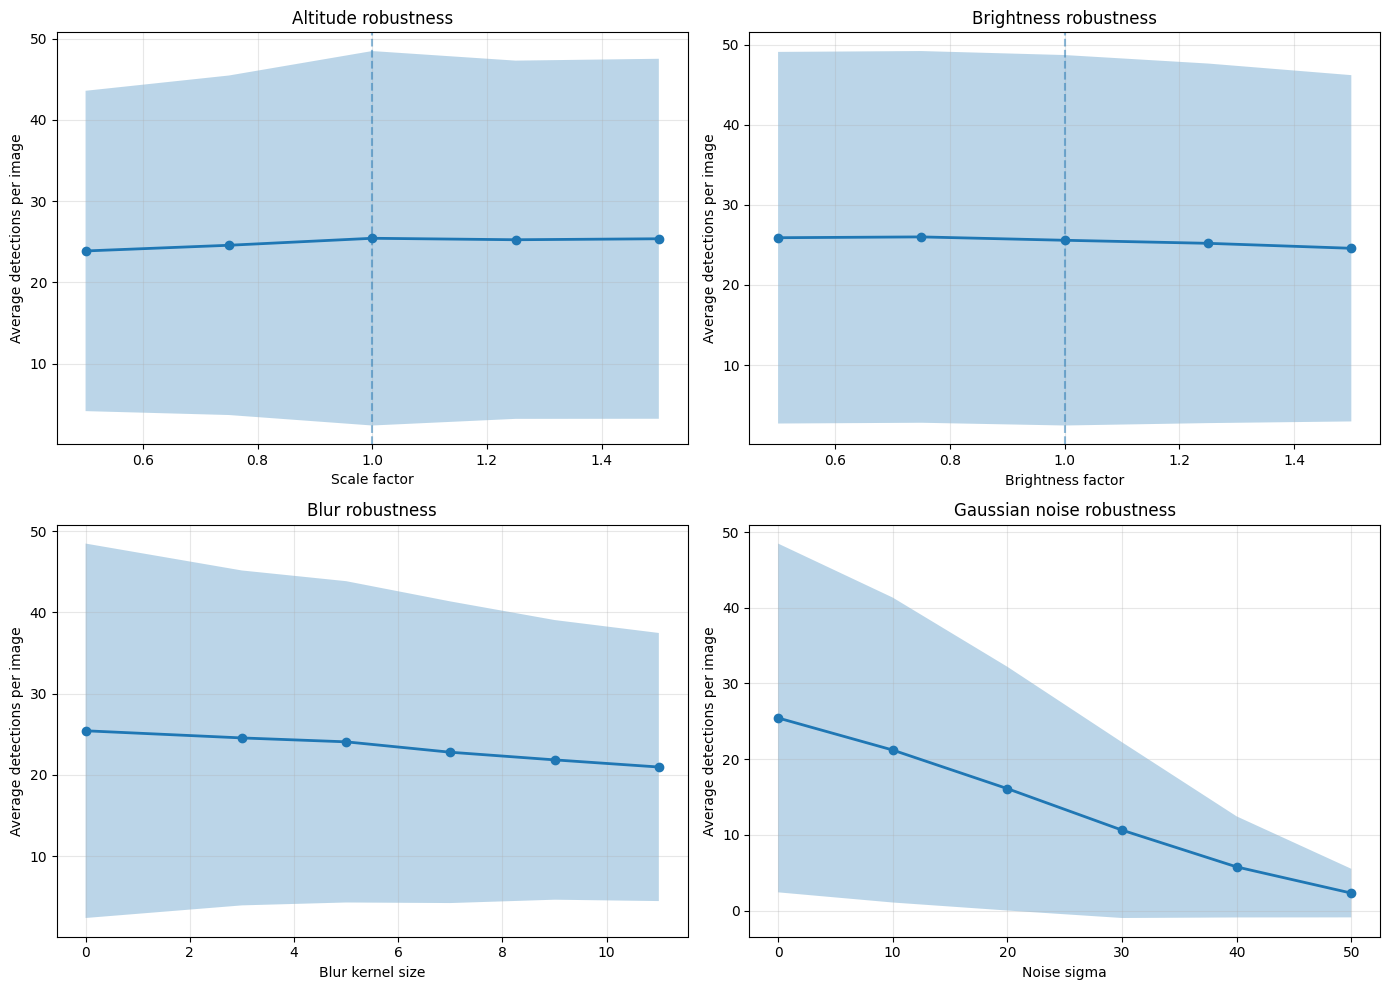

In [4]:
import sys
sys.path.append('..')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm
import time

model = YOLO('../models/yolo26n_visdrone/weights/best.pt')

val_img_dir = Path('../data/processed/val/images')
test_images = list(val_img_dir.glob('*.jpg'))[:50]

print(f"Robustness tests on {len(test_images)} images")

# Altitude robustness (scale)

scale_factors = [0.5, 0.75, 1.0, 1.25, 1.5]
altitude_results = []

for scale in tqdm(scale_factors):
    detections = []
    inference_times = []

    for img_path in test_images:
        img = cv2.imread(str(img_path))

        h, w = img.shape[:2]
        new_w = int(w * scale)
        new_h = int(h * scale)
        img_resized = cv2.resize(img, (new_w, new_h))

        start = time.time()
        results = model.predict(img_resized, verbose=False, conf=0.25)
        inference_times.append(time.time() - start)

        detections.append(len(results[0].boxes))

    altitude_results.append({
        "scale": scale,
        "avg_detections": np.mean(detections),
        "std_detections": np.std(detections),
        "avg_inference_time_ms": np.mean(inference_times) * 1000,
        "fps": 1 / np.mean(inference_times)
    })

df_altitude = pd.DataFrame(altitude_results)
print(df_altitude)


# Brightness robustness

brightness_factors = [0.5, 0.75, 1.0, 1.25, 1.5]
brightness_results = []

for brightness in tqdm(brightness_factors):
    detections = []

    for img_path in test_images:
        img = cv2.imread(str(img_path))

        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * brightness, 0, 255)
        img_adjusted = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

        results = model.predict(img_adjusted, verbose=False, conf=0.25)
        detections.append(len(results[0].boxes))

    brightness_results.append({
        "brightness": brightness,
        "avg_detections": np.mean(detections),
        "std_detections": np.std(detections)
    })

df_brightness = pd.DataFrame(brightness_results)
print(df_brightness)


# Blur robustness

blur_kernels = [0, 3, 5, 7, 9, 11]
blur_results = []

for kernel_size in tqdm(blur_kernels):
    detections = []

    for img_path in test_images:
        img = cv2.imread(str(img_path))

        if kernel_size > 0:
            img_blurred = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
        else:
            img_blurred = img

        results = model.predict(img_blurred, verbose=False, conf=0.25)
        detections.append(len(results[0].boxes))

    blur_results.append({
        "blur_kernel": kernel_size,
        "avg_detections": np.mean(detections),
        "std_detections": np.std(detections)
    })

df_blur = pd.DataFrame(blur_results)
print(df_blur)


# Noise robustness

noise_levels = [0, 10, 20, 30, 40, 50]
noise_results = []

for noise_sigma in tqdm(noise_levels):
    detections = []

    for img_path in test_images:
        img = cv2.imread(str(img_path)).astype(np.float32)

        if noise_sigma > 0:
            noise = np.random.normal(0, noise_sigma, img.shape)
            img_noisy = np.clip(img + noise, 0, 255).astype(np.uint8)
        else:
            img_noisy = img.astype(np.uint8)

        results = model.predict(img_noisy, verbose=False, conf=0.25)
        detections.append(len(results[0].boxes))

    noise_results.append({
        "noise_sigma": noise_sigma,
        "avg_detections": np.mean(detections),
        "std_detections": np.std(detections)
    })

df_noise = pd.DataFrame(noise_results)
print(df_noise)


# Plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(df_altitude["scale"], df_altitude["avg_detections"], "o-", linewidth=2)
ax.fill_between(
    df_altitude["scale"],
    df_altitude["avg_detections"] - df_altitude["std_detections"],
    df_altitude["avg_detections"] + df_altitude["std_detections"],
    alpha=0.3
)
ax.axvline(1.0, linestyle="--", alpha=0.5)
ax.set_xlabel("Scale factor")
ax.set_ylabel("Average detections per image")
ax.set_title("Altitude robustness")
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(df_brightness["brightness"], df_brightness["avg_detections"], "o-", linewidth=2)
ax.fill_between(
    df_brightness["brightness"],
    df_brightness["avg_detections"] - df_brightness["std_detections"],
    df_brightness["avg_detections"] + df_brightness["std_detections"],
    alpha=0.3
)
ax.axvline(1.0, linestyle="--", alpha=0.5)
ax.set_xlabel("Brightness factor")
ax.set_ylabel("Average detections per image")
ax.set_title("Brightness robustness")
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(df_blur["blur_kernel"], df_blur["avg_detections"], "o-", linewidth=2)
ax.fill_between(
    df_blur["blur_kernel"],
    df_blur["avg_detections"] - df_blur["std_detections"],
    df_blur["avg_detections"] + df_blur["std_detections"],
    alpha=0.3
)
ax.set_xlabel("Blur kernel size")
ax.set_ylabel("Average detections per image")
ax.set_title("Blur robustness")
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(df_noise["noise_sigma"], df_noise["avg_detections"], "o-", linewidth=2)
ax.fill_between(
    df_noise["noise_sigma"],
    df_noise["avg_detections"] - df_noise["std_detections"],
    df_noise["avg_detections"] + df_noise["std_detections"],
    alpha=0.3
)
ax.set_xlabel("Noise sigma")
ax.set_ylabel("Average detections per image")
ax.set_title("Gaussian noise robustness")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/plots/robustness_analysis_yolo26.png", dpi=150, bbox_inches="tight")
plt.show()


df_altitude.to_csv("../outputs/robustness_altitude_yolo26.csv", index=False)
df_brightness.to_csv("../outputs/robustness_brightness_yolo26.csv", index=False)
df_blur.to_csv("../outputs/robustness_blur_yolo26.csv", index=False)
df_noise.to_csv("../outputs/robustness_noise_yolo26.csv", index=False)